# Comparison with other block encoding techniques

In [1]:
# Imports
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

from block_encoding import generate_laplacian_block_encoding, ShiftDown, ShiftUp
from utils import get_circuit_unitary, plot_heatmap, lap1d_fd, generate_laplacian, prepare_v_vector
from fable import fable

import warnings

warnings.filterwarnings(
    "ignore",
    message=".*encountered in det.*",
    category=RuntimeWarning,
)

## Other block-encodings

### 1. Camps et al. 2023

This work provides for explicit quantum circuits to block encode a 1D Laplacian matrix, with either Dirichlet or Periodic boundary conditions.

In [2]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import RYGate, StatePreparation


def camps_banded_circulant_mat(
    nq, alpha, beta, gamma, tridiag=False, save_unitary=True
):
    """https://arxiv.org/pdf/2203.10236"""

    assert 0 <= alpha
    assert alpha <= 2
    assert abs(beta) <= 1
    assert abs(gamma) <= 1

    j_reg = QuantumRegister(nq, "j")
    data_reg = QuantumRegister(1, "data")
    l_reg = QuantumRegister(2, "l")

    qc = QuantumCircuit(j_reg, l_reg, data_reg)

    # Diffusion
    qc.h(l_reg)

    # OA
    theta0 = 2 * np.arccos(alpha - 1)
    theta1 = 2 * np.arccos(beta)
    theta2 = 2 * np.arccos(gamma)

    qc.append(RYGate(theta0).control(2, ctrl_state="00"), l_reg[:] + data_reg[:])
    qc.append(RYGate(theta1).control(2, ctrl_state="01"), l_reg[:] + data_reg[:])
    qc.append(RYGate(theta2).control(2, ctrl_state="10"), l_reg[:] + data_reg[:])

    if tridiag:
        qc.append(
            RYGate(np.pi - theta1).control(nq + 2, ctrl_state="1" * nq + "01"),
            l_reg[:] + j_reg[:] + data_reg[:],
        )
        qc.append(
            RYGate(np.pi - theta2).control(nq + 2, ctrl_state="0" * nq + "10"),
            l_reg[:] + j_reg[:] + data_reg[:],
        )

    # OC
    qc.append(ShiftUp(nq).control(1), [l_reg[0]] + j_reg[:])
    qc.append(ShiftDown(nq).control(1), [l_reg[1]] + j_reg[:])

    # Diffusion
    qc.h(l_reg)

    if save_unitary:
        qc.save_unitary()

    return qc

### 2. Sunderhauff et al. 2024

This work provides for explicit quantum circuits to block encode a 2D Laplacian matrix, with either Dirichlet boundary conditions along both the dimensions.

In [3]:
import math
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.library import *
from qiskit.quantum_info import Operator


def unique_val_lap(laplacian, Nx):
    """Extract unique diagonal values from a 2D Laplacian matrix."""
    unique_values = [
        laplacian.diagonal(0)[0],  # Main diagonal (A0)
        laplacian.diagonal(1)[0],  # Next lower diagonal (A1)
        laplacian.diagonal(Nx)[0],  # Final diagonal (A2)
    ]
    return unique_values


def make_incrementer(n: int):
    circ = QuantumCircuit(n, name=f"INC{n}")
    for i in range(n - 1, 0, -1):
        circ.mcx(list(range(i)), i)
    circ.x(0)
    return circ.to_gate()


def make_decrementer(n: int):
    inc = make_incrementer(n)
    dec = inc.inverse()
    dec.name = f"DEC{n}"
    return dec


def prep_lap(reg: QuantumRegister, vec: list[float]):
    qc = QuantumCircuit(reg)
    prep = StatePreparation(vec)
    qc.append(prep, reg)
    return qc


def unprep_lap(reg: QuantumRegister, vec: list[float]):
    prep_qc = prep_lap(reg, vec)
    unitary = Operator(prep_qc).data
    inv_unitary = np.conj(unitary.T)
    qc = QuantumCircuit(reg)
    prep_inv_gate = UnitaryGate(inv_unitary)
    qc.append(prep_inv_gate, reg)
    return qc


def oracle_org(qc, dl_reg, j_reg, s_reg, j1, j2, jx, jy):
    oracle_100 = XGate().control(3, ctrl_state="001")
    qc.append(oracle_100, [s_reg[0], s_reg[1], s_reg[2], dl_reg[0]])
    oracle_01_jy = XGate().control(j1 + 1, ctrl_state=("1" + "0" * j1))
    qc.append(oracle_01_jy, jx + [s_reg[1], dl_reg[0]])
    oracle_01_jx = XGate().control(j2 + 1, ctrl_state=("1" + "0" * j2))
    qc.append(oracle_01_jx, jy + [s_reg[2], dl_reg[0]])


def oracle_d(qc: QuantumCircuit, TM: list[float], data_regs: list, s_reg: list):
    """
    Apply a multi‐controlled RX on each data qubit in data_regs,
    with angles 2*arccos(TM[i]) controlled on the bitstring i of s_reg[1:].

    Args:
        qc        : your QuantumCircuit
        TM        : list of length 2**n_controls of amplitudes
        data_regs : list of target qubits (e.g. [data_reg[0]])
        s_reg     : full s register (we’ll use s_reg[1:] as controls)
    """
    controls = [s_reg[1], s_reg[2]]
    n_ctrl = len(controls)

    if len(TM) != 2**n_ctrl:
        raise ValueError(f"TM must have length 2**{n_ctrl} (got {len(TM)})")

    for i, amp in enumerate(TM):
        angle = 2 * np.arccos(amp)
        ctrl_state = format(i, "02b")
        gate = RXGate(angle).control(2, ctrl_state=ctrl_state)
        qc.append(gate, controls + [data_regs[0]])

    return qc


def sunderhauf_block_encoding(
    Nx, Ny, scaled_laplacian, v_normed=None, save_unitary=True
):
    "https://quantum-journal.org/papers/q-2024-01-11-1226/"

    unique_values_laplacian = unique_val_lap(scaled_laplacian, Nx)
    unique_values_laplacian.append(0)

    data_reg = QuantumRegister(1, "data")
    dlt_reg = QuantumRegister(1, "dlt")
    s_reg = QuantumRegister(3, "s")  # Corresponds to s0, s1, s2
    j1, j2 = int(math.log2(Nx)), int(math.log2(Ny))
    j_reg = QuantumRegister(j1 + j2, "j")
    jx, jy = j_reg[:j1], j_reg[j1:]
    qc = QuantumCircuit(j_reg, s_reg, dlt_reg, data_reg)

    if v_normed is not None:
        qc.append(StatePreparation(v_normed), j_reg)

    vec = [
        np.sqrt(1 / 5),
        0,
        np.sqrt(1 / 5),
        np.sqrt(1 / 5),
        np.sqrt(1 / 5),
        np.sqrt(1 / 5),
        0,
        0,
    ]

    prep = prep_lap(s_reg, vec)
    qc.append(prep, s_reg)

    add_1_to_jy = make_incrementer(j2).control(2, ctrl_state="10")
    add_1_to_j = make_incrementer(int(j1 + j2)).control(2, ctrl_state="10")
    qc.append(add_1_to_jy, [s_reg[0], s_reg[2]] + jy)  # [::-1]
    qc.append(add_1_to_j, [s_reg[0], s_reg[1]] + list(j_reg))  # [::-1]

    oracle_org(qc, dlt_reg, j_reg, s_reg, j1, j2, jx, jy)
    qc.z(data_reg[0])
    oracle_d(qc, unique_values_laplacian, data_reg, s_reg)
    qc.cx(s_reg[1], s_reg[0])
    qc.cx(s_reg[2], s_reg[0])

    sub_1_to_jx = make_decrementer(int(j1 + j2)).control(2, ctrl_state="10")
    qc.append(sub_1_to_jx, [s_reg[0], s_reg[1]] + list(j_reg))
    sub_1_to_j = make_decrementer(j2).control(2, ctrl_state="10")
    qc.append(sub_1_to_j, [s_reg[0], s_reg[2]] + jy)

    prep_dagger = unprep_lap(s_reg, vec)
    qc.append(prep_dagger, s_reg)

    if save_unitary:
        qc.save_unitary()

    return qc

### BITBLE

In [4]:
def angle_search_bin_tree(amps):
    l = len(amps)

    if l == 2:
        ssra = np.linalg.norm(amps)

        if np.isclose(ssra, 0.0):
            vals = 0.0

        else:
            vals = np.acos(amps[0] / ssra)

    else:
        ssra1, vals1 = angle_search_bin_tree(amps[: l // 2])
        ssra2, vals2 = angle_search_bin_tree(amps[l // 2 :])

        ssra = np.append(ssra1, ssra2)
        vals = np.append(vals1, vals2)

    return ssra, vals


def positive_transform(amps):
    N = len(amps)
    phis = np.zeros(N // 2)
    ssra = np.zeros(N // 2)

    for i in range(N // 2):
        if np.linalg.norm(amps[2 * i : 2 * i + 2]) == 0:
            ssra[i] = 0
            phis[i] = 0

        else:
            num = amps[2 * i : 2 * i + 2]
            ssra[i] = np.linalg.norm(num)
            num /= ssra[i]
            cplex = num[0] + 1j * num[1]
            phis[i] = np.remainder(np.angle(cplex), 2 * np.pi)

    return ssra, phis


def angle_compute(ctrl_type, norm_or_phase):
    N = len(norm_or_phase)
    n = int(np.log2(N))

    if ctrl_type == "ry":
        phis = np.zeros(N - 1)

        ssra, phi = positive_transform(norm_or_phase)
        phis[N // 2 - 1 : N - 1] = phi

        for i in range(n - 2, -1, -1):
            ssra, phi = angle_search_bin_tree(ssra)
            phis[2**i - 1 : 2 ** (i + 1) - 1] = phi

        converted_angles = np.remainder(2 * phis, 4 * np.pi)

    return converted_angles

def gray_code(x):
    return x ^ (x >> 1)


def gray_permutation(a):
    k = int(np.log2(len(a)))
    b = np.zeros(a.shape)

    for i in range(2**k):
        b[i, :] = a[gray_code(i), :]

    return b


def sfwht(a):
    b = a.copy()
    print(b.shape)

    rows = a.shape[0]
    k = int(np.log2(rows))

    for h in range(1, k+1):
        jump = 2 ** h
        half = 2 ** (h - 1)

        for i in range(0, rows, jump):
            for j in range(i, i + half):
                x = b[j, :].copy()
                y = b[j + half, :].copy()

                b[j, :] = (x + y) / 2
                b[j + half, :] = (x - y) / 2

    return b


def uniformly_rotation_angle(theta):
    return gray_permutation(sfwht(theta))


def bitble(matrix, compr_type, compr_val):
    N = len(matrix)
    n = int(np.log2(N))
    phis = np.zeros((N - 1, N + 1))

    for i in range(N):
        phis[:, i] = angle_compute("ry", matrix[:, i])

    norm_cols = np.linalg.norm(matrix, axis=0)
    norm_cols /= np.linalg.norm(norm_cols)
    phis[:, -1] = angle_compute("ry", norm_cols)

    for i in range(2, n + 1):
        start = 2 ** (i-1) - 1
        end = 2 ** i - 1
        phis[start : end, :] = uniformly_rotation_angle(phis[start : end, :])

    phis_global = phis[:, -1]
    phis = uniformly_rotation_angle(phis[:, :2**n])
    a = []

## Benchmarking

### Metrics used: circuit depth, 2-qubit gate count, and total number of gates

For uniformity, we transpile all the block encoding quantum circuits using the basis gates of the Heron processor of IBM.

#### 2D Laplacian wth Dirichlet boundary conditions

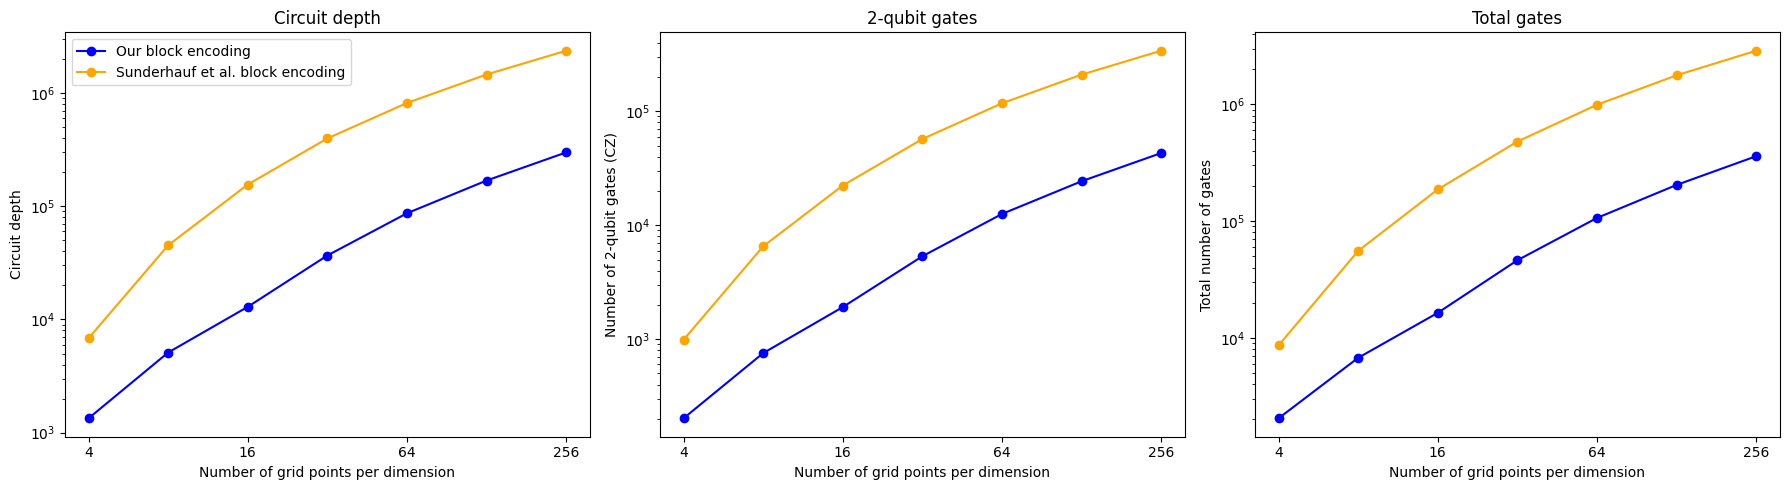

In [ ]:
basis_gates = ["cz", "id", "rx", "rz", "rzz", "sx", "x"]  # Heron QPU basis gates

nq = list(range(2, 9))
npoints = 2 ** np.array(nq)

our_be_2qg = []
sunderhauf_be_2qg = []

our_be_total_gates = []
sunderhauf_be_total_gates = []

our_be_depth = []
sunderhauf_be_depth = []


for nq1 in nq:
    # Correct Laplacian matrix
    lap = generate_laplacian((2**nq1, 2**nq1), analytic_normalize=True)

    # Our block encoding
    qc = generate_laplacian_block_encoding([nq1, nq1], save_unitary=False)
    transpiled = transpile(qc, basis_gates=basis_gates, optimization_level=0)

    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts["rzz"]

    our_be_depth.append(transpiled.depth())
    our_be_2qg.append(twoq_count)
    our_be_total_gates.append(sum(counts.values()))

    # Sunderhauff et al. block encoding
    qc = sunderhauf_block_encoding(2**nq1, 2**nq1, lap, save_unitary=False)
    transpiled = transpile(qc, basis_gates=basis_gates, optimization_level=0)

    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts["rzz"]

    sunderhauf_be_depth.append(transpiled.depth())
    sunderhauf_be_2qg.append(twoq_count)
    sunderhauf_be_total_gates.append(sum(counts.values()))


fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, squeeze=False)

# axes is shape (1, 3)
ax = axes[0]  # convenience view

# -------------------------
# Circuit depth
# -------------------------
ax[0].plot(npoints, our_be_depth, "o-", color="blue", label="Our block encoding")
ax[0].plot(
    npoints,
    sunderhauf_be_depth,
    "o-",
    color="orange",
    label="Sunderhauf et al. block encoding",
)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_title("Circuit depth")
ax[0].set_ylabel("Circuit depth")
ax[0].legend()

# -------------------------
# 2-qubit gates
# -------------------------
ax[1].plot(npoints, our_be_2qg, "o-", color="blue")
ax[1].plot(
    npoints,
    sunderhauf_be_2qg,
    "o-",
    color="orange",
)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_title("2-qubit gates")
ax[1].set_ylabel("Number of 2-qubit gates (CZ)")

# -------------------------
# Total gates
# -------------------------
ax[2].plot(npoints, our_be_total_gates, "o-", color="blue")
ax[2].plot(
    npoints,
    sunderhauf_be_total_gates,
    "o-",
    color="orange",
)
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_title("Total gates")
ax[2].set_ylabel("Total number of gates")

# -------------------------
# Shared formatting
# -------------------------
for a in ax:
    a.set_xlabel("Number of grid points per dimension")
    a.set_xticks(npoints[::2], labels=npoints[::2])
    a.xaxis.set_minor_locator(plt.NullLocator())

plt.tight_layout()
plt.show()

#### 1D Laplacian with Dirichlet/periodic BCs

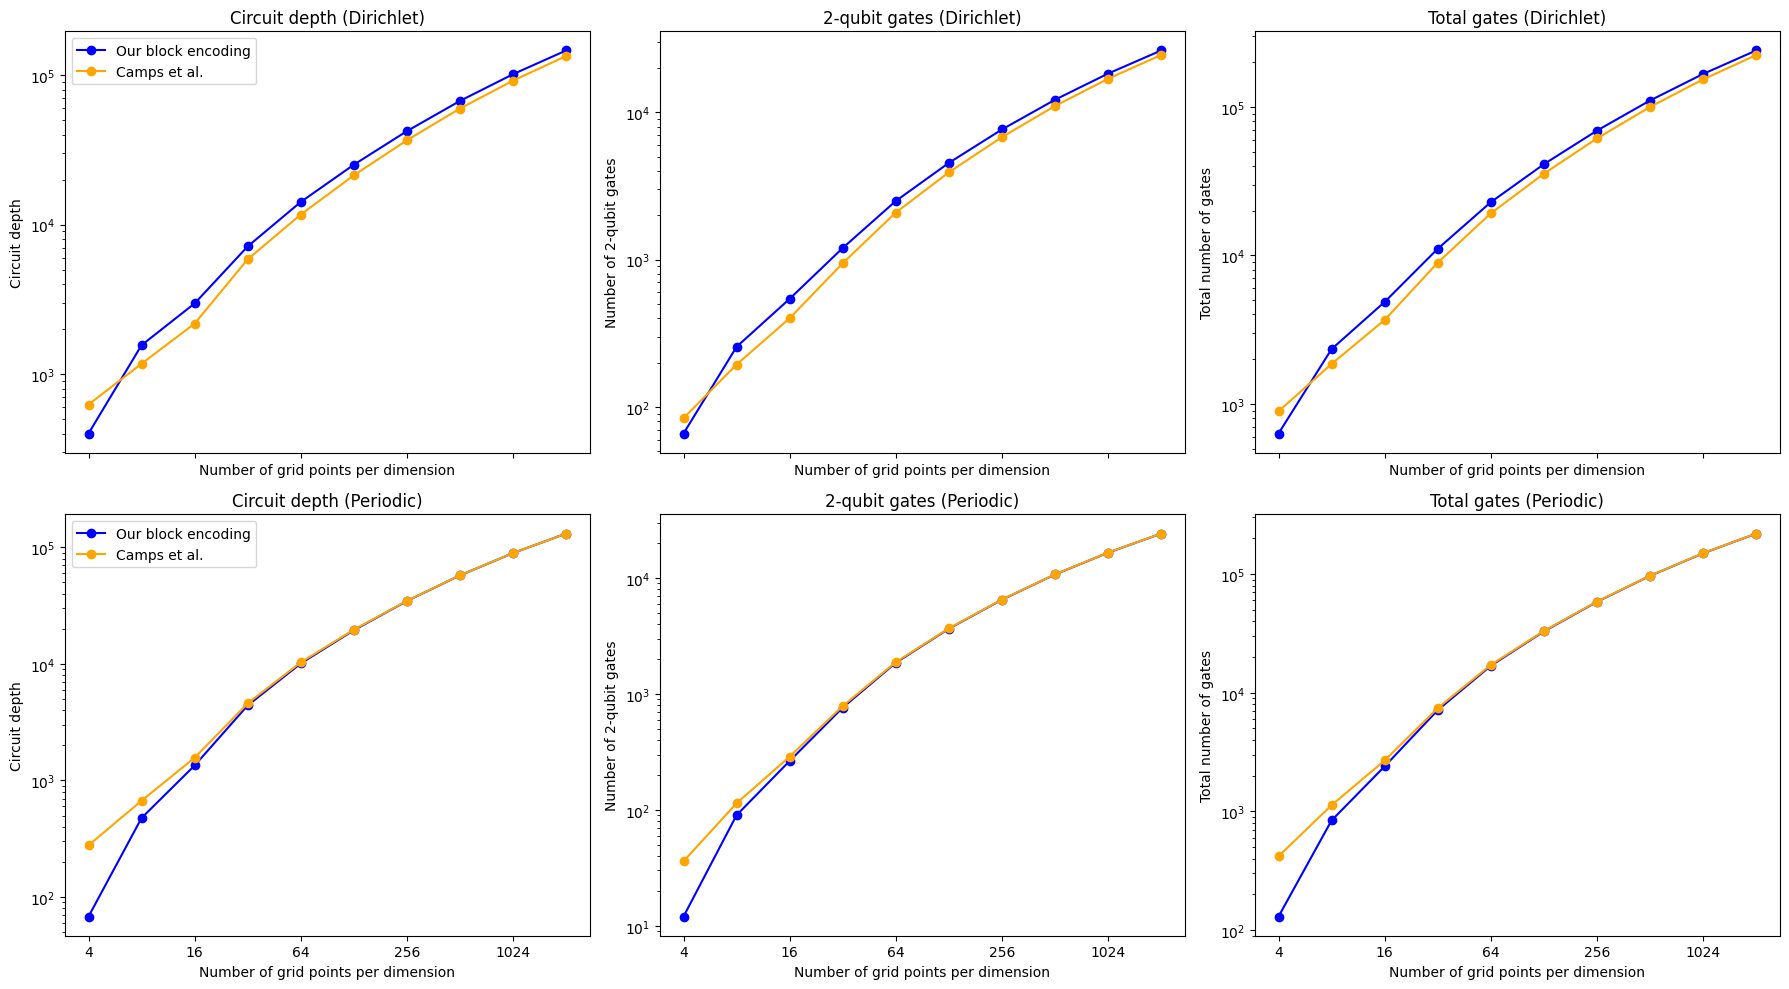

In [6]:
# 1D Laplacians with Dirichlet/periodic BCs
basis_gates = ["cz", "id", "rx", "rz", "rzz", "sx", "x"]  # Heron QPU basis gates

nqs = list(range(2, 12))
npoints = 2 ** np.array(nqs)

our_be_dbc_depth = []
our_be_pbc_depth = []
camps_be_dbc_depth = []
camps_be_pbc_depth = []

our_be_dbc_2qg = []
our_be_pbc_2qg = []
camps_be_dbc_2qg = []
camps_be_pbc_2qg = []

our_be_dbc_total = []
our_be_pbc_total = []
camps_be_dbc_total = []
camps_be_pbc_total = []

for nq in nqs:
    # Dirichlet BCs
    # - Our block-encoding
    qc = generate_laplacian_block_encoding([nq], save_unitary=False)
    transpiled = transpile(qc, basis_gates=basis_gates, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts["rzz"]

    our_be_dbc_depth.append(transpiled.depth())
    our_be_dbc_2qg.append(twoq_count)
    our_be_dbc_total.append(sum(counts.values()))

    # - Camps et al.
    qc = camps_banded_circulant_mat(nq, 0.5, -0.25, -0.25, True, False)
    transpiled = transpile(qc, basis_gates=basis_gates, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts["rzz"]

    camps_be_dbc_depth.append(transpiled.depth())
    camps_be_dbc_2qg.append(twoq_count)
    camps_be_dbc_total.append(sum(counts.values()))

    # Periodic BCs
    # - Our block-encoding
    qc = generate_laplacian_block_encoding([nq], bcs=["periodic"], save_unitary=False)
    transpiled = transpile(qc, basis_gates=basis_gates, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts["rzz"]

    our_be_pbc_depth.append(transpiled.depth())
    our_be_pbc_2qg.append(twoq_count)
    our_be_pbc_total.append(sum(counts.values()))

    # - Camps et al.
    qc = camps_banded_circulant_mat(nq, 0.5, -0.25, -0.25, False, False)
    transpiled = transpile(qc, basis_gates=basis_gates, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts["rzz"]

    camps_be_pbc_depth.append(transpiled.depth())
    camps_be_pbc_2qg.append(twoq_count)
    camps_be_pbc_total.append(sum(counts.values()))


fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

# =========================
# Row 1: Dirichlet BC
# =========================

# Circuit depth
axes[0, 0].plot(
    npoints, our_be_dbc_depth, "o-", color="blue", label="Our block encoding"
)
axes[0, 0].plot(npoints, camps_be_dbc_depth, "o-", color="orange", label="Camps et al.")
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Circuit depth (Dirichlet)")
axes[0, 0].set_ylabel("Circuit depth")
axes[0, 0].legend()

# 2-qubit gates
axes[0, 1].plot(npoints, our_be_dbc_2qg, "o-", color="blue")
axes[0, 1].plot(npoints, camps_be_dbc_2qg, "o-", color="orange")
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("2-qubit gates (Dirichlet)")
axes[0, 1].set_ylabel("Number of 2-qubit gates")

# Total gates
axes[0, 2].plot(npoints, our_be_dbc_total, "o-", color="blue")
axes[0, 2].plot(npoints, camps_be_dbc_total, "o-", color="orange")
axes[0, 2].set_yscale("log")
axes[0, 2].set_title("Total gates (Dirichlet)")
axes[0, 2].set_ylabel("Total number of gates")

# =========================
# Row 2: Periodic BC
# =========================

# Circuit depth
axes[1, 0].plot(
    npoints, our_be_pbc_depth, "o-", color="blue", label="Our block encoding"
)
axes[1, 0].plot(npoints, camps_be_pbc_depth, "o-", color="orange", label="Camps et al.")
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Circuit depth (Periodic)")
axes[1, 0].set_ylabel("Circuit depth")
axes[1, 0].legend()

# 2-qubit gates
axes[1, 1].plot(npoints, our_be_pbc_2qg, "o-", color="blue")
axes[1, 1].plot(npoints, camps_be_pbc_2qg, "o-", color="orange")
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("2-qubit gates (Periodic)")
axes[1, 1].set_ylabel("Number of 2-qubit gates")

# Total gates
axes[1, 2].plot(npoints, our_be_pbc_total, "o-", color="blue")
axes[1, 2].plot(npoints, camps_be_pbc_total, "o-", color="orange")
axes[1, 2].set_yscale("log")
axes[1, 2].set_title("Total gates (Periodic)")
axes[1, 2].set_ylabel("Total number of gates")

# =========================
# Shared formatting
# =========================
for ax in axes.flat:
    ax.set_xscale("log")
    ax.set_xlabel("Number of grid points per dimension")
    ax.set_xticks(npoints[::2], labels=npoints[::2])
    ax.xaxis.set_minor_locator(plt.NullLocator())

plt.tight_layout()
plt.show()

#### 3D Laplacian with mixed boundary conditions

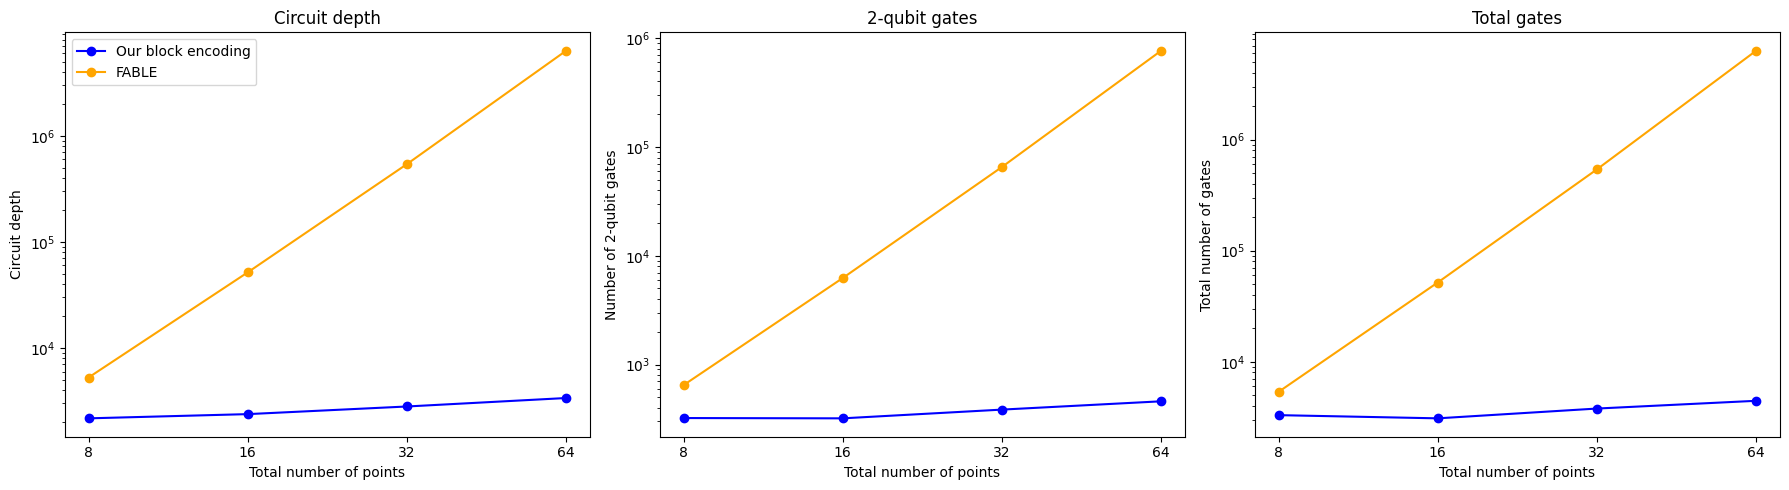

In [7]:
basis_gates = ["cz", "id", "rx", "rz", "rzz", "sx", "x"]  # Heron QPU basis gates

deltas = [1.0, 0.5, 1.0]
nqs = list(range(3, 7))
npoints = 2 ** np.array(nqs)

our_be_3d_depth = []
fable_3d_depth = []

our_be_3d_2qg = []
fable_3d_2qg = []

our_be_3d_total = []
fable_3d_total = []

for nq in nqs:
    # - Our block encoding
    qc = generate_laplacian_block_encoding(
        [(nq + 2) // 3, (nq + 1) // 3, nq // 3],
        deltas=deltas,
        bcs=["periodic", "dirichlet", "neumann"],
        save_unitary=False,
    )
    transpiled = transpile(qc, basis_gates=basis_gates, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts["rzz"]

    our_be_3d_depth.append(transpiled.depth())
    our_be_3d_2qg.append(twoq_count)
    our_be_3d_total.append(sum(counts.values()))

    # - FABLE
    matrix = generate_laplacian(
        [2**nq, 2**nq], deltas, ["periodic", "dirichlet", "neumann"]
    )
    qc_fable, _ = fable(matrix.toarray(), 0)
    transpiled = transpile(qc_fable, basis_gates=basis_gates, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts.get("rzz", 0)

    fable_3d_depth.append(transpiled.depth())
    fable_3d_2qg.append(twoq_count)
    fable_3d_total.append(sum(counts.values()))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, squeeze=False)

# axes is shape (1, 3)
ax = axes[0]  # convenience view

# -------------------------
# Circuit depth
# -------------------------
ax[0].plot(npoints, our_be_3d_depth, "o-", color="blue", label="Our block encoding")
ax[0].plot(
    npoints,
    fable_3d_depth,
    "o-",
    color="orange",
    label="FABLE",
)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_title("Circuit depth")
ax[0].set_ylabel("Circuit depth")
ax[0].legend()

# -------------------------
# 2-qubit gates
# -------------------------
ax[1].plot(npoints, our_be_3d_2qg, "o-", color="blue")
ax[1].plot(
    npoints,
    fable_3d_2qg,
    "o-",
    color="orange",
)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_title("2-qubit gates")
ax[1].set_ylabel("Number of 2-qubit gates")

# -------------------------
# Total gates
# -------------------------
ax[2].plot(npoints, our_be_3d_total, "o-", color="blue")
ax[2].plot(
    npoints,
    fable_3d_total,
    "o-",
    color="orange",
)
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_title("Total gates")
ax[2].set_ylabel("Total number of gates")

# -------------------------
# Shared formatting
# -------------------------
for a in ax:
    a.set_xlabel("Total number of points")
    a.set_xticks(npoints, labels=npoints)
    a.xaxis.set_major_formatter(ScalarFormatter())
    a.xaxis.set_minor_formatter(ScalarFormatter())
    a.xaxis.set_minor_locator(plt.NullLocator())

plt.tight_layout()
plt.show()

## Success probability analysis
#### 1D Laplacian with Dirichlet/periodic/von Neumann BC

In [4]:
def v_1d(x):
    return np.sin(2 * np.pi * x)

def v_2d(x, y):
    return np.sin(2 * np.pi * (x + y))

def v_3d(x, y, z):
    return np.sin(2 * np.pi * (x + y + z))

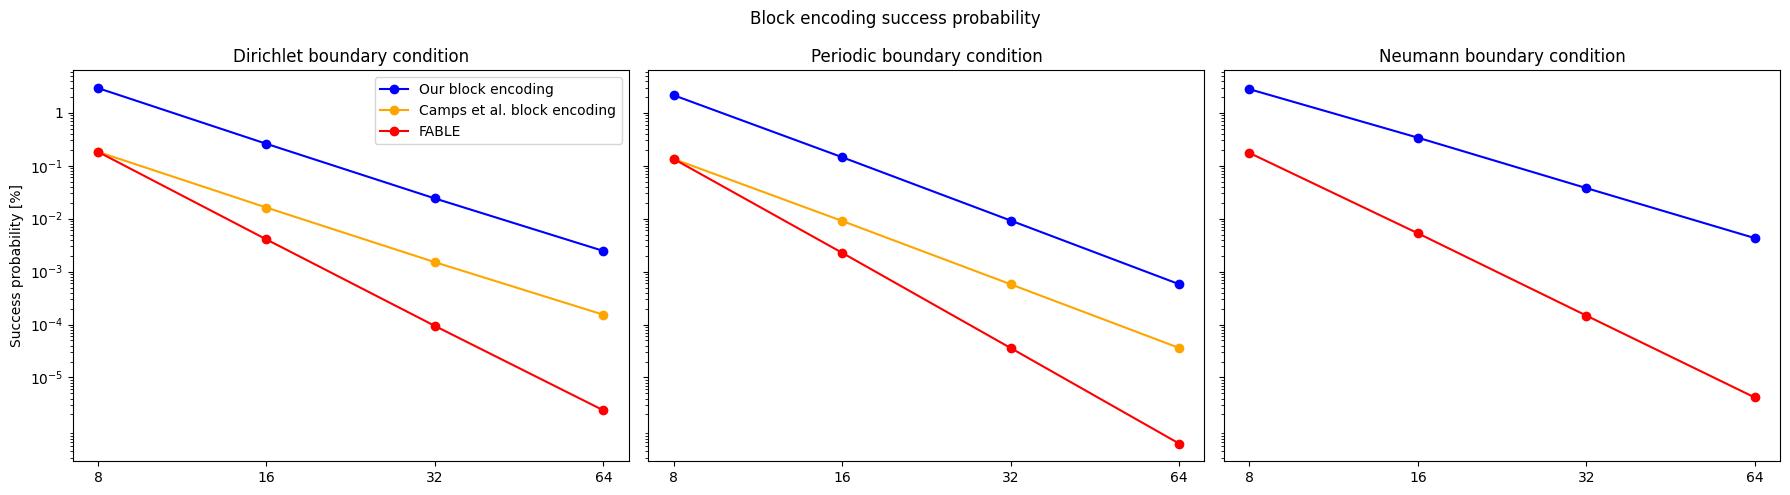

In [ ]:
nqs = list(range(3, 7))
n_points = 2 ** np.array(nqs)

sprob_our_be_1d_dbc = []
sprob_camps_be_1d_dbc = []
sprob_fable_1d_dbc = []

sprob_our_be_1d_pbc = []
sprob_camps_be_1d_pbc = []
sprob_fable_1d_pbc = []

sprob_our_be_1d_nbc = []
sprob_fable_1d_nbc = []

for i in range(len(nqs)):
    nq = nqs[i]
    x = np.linspace(0, 1, 2**nq, endpoint=False)
    v = v_1d(x)
    v_normed = v / np.linalg.norm(v)

    # Dirichlet
    # Our block encoding
    qc = generate_laplacian_block_encoding([nq], vs=v_normed)
    unitary = get_circuit_unitary(qc, [nq])
    sprob_our_be_1d_dbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # Camps et al.
    qc = QuantumCircuit(nq + 3)
    qc.append(StatePreparation(v_normed), range(nq))
    qc_camps_be = camps_banded_circulant_mat(nq, 0.5, -0.25, -0.25, True, True)
    qc.append(qc_camps_be, qc.qubits)
    unitary = get_circuit_unitary(qc, [nq])
    sprob_camps_be_1d_dbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # FABLE
    qc = QuantumCircuit(2 * nq + 1)
    qc.append(StatePreparation(v_normed), range(nq))
    qc_fable, _ = fable(generate_laplacian((2**nq,)).toarray(), 0)
    qc.append(qc_fable, qc.qubits)
    qc.save_unitary()
    unitary = get_circuit_unitary(qc, [nq])
    sprob_fable_1d_dbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # Periodic
    # Our block encoding
    qc = generate_laplacian_block_encoding([nq], bcs=["periodic"], vs=v_normed)
    unitary = get_circuit_unitary(qc, [nq])
    sprob_our_be_1d_pbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # Camps et al.
    qc = QuantumCircuit(nq + 3)
    qc.append(StatePreparation(v_normed), range(nq))
    qc_camps_be = camps_banded_circulant_mat(nq, 0.5, -0.25, -0.25, False, True)
    qc.append(qc_camps_be, qc.qubits)
    unitary = get_circuit_unitary(qc, [nq])
    sprob_camps_be_1d_pbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # FABLE
    qc = QuantumCircuit(2 * nq + 1)
    qc.append(StatePreparation(v_normed), range(nq))
    qc_fable, _ = fable(generate_laplacian((2**nq,), bcs=["periodic"]).toarray(), 0)
    qc.append(qc_fable, qc.qubits)
    qc.save_unitary()
    unitary = get_circuit_unitary(qc, [nq])
    sprob_fable_1d_pbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # Neumann
    # Our block encoding
    qc = generate_laplacian_block_encoding([nq], vs=v_normed, bcs=["neumann"])
    unitary = get_circuit_unitary(qc, [nq])
    sprob_our_be_1d_nbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # FABLE
    qc = QuantumCircuit(2 * nq + 1)
    qc.append(StatePreparation(v_normed), range(nq))
    qc_fable, _ = fable(generate_laplacian((2**nq,), bcs=["neumann"]).toarray(), 0)
    qc.append(qc_fable, qc.qubits)
    qc.save_unitary()
    unitary = get_circuit_unitary(qc, [nq])
    sprob_fable_1d_nbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True, squeeze=False)
ax = axes[0]

ax[0].plot(n_points, sprob_our_be_1d_dbc, "o-",label="Our block encoding", color="blue")
ax[0].plot(
    n_points, sprob_camps_be_1d_dbc, "o-",label="Camps et al. block encoding", color="orange"
)
ax[0].plot(n_points, sprob_fable_1d_dbc, "o-",label="FABLE", color="red")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xticks([8, 16, 32, 64])
ax[0].set_xticklabels(["8", "16", "32", "64"])
ax[0].xaxis.set_minor_locator(plt.NullLocator())
ax[0].set_yticks([10**(-i) for i in range(8)])
ax[0].set_yticklabels(["1"] + [f"$10^{{{-i}}}$" for i in range(1, 6)])
ax[0].set_ylabel("Success probability [%]")
ax[0].legend()
ax[0].set_title("Dirichlet boundary condition")

ax[1].plot(n_points, sprob_our_be_1d_pbc, "o-", label="Our block encoding", color="blue")
ax[1].plot(
    n_points,
    sprob_camps_be_1d_pbc,
    "o-",
    label="Camps et al. block encoding",
    color="orange",
)
ax[1].plot(n_points, sprob_fable_1d_pbc, "o-", label="FABLE", color="red")
ax[1].set_title("Periodic boundary condition")

ax[2].plot(n_points, sprob_our_be_1d_nbc, "o-", label="Our block encoding", color="blue")
ax[2].plot(n_points, sprob_fable_1d_nbc, "o-",label="FABLE", color="red")
ax[2].set_title("Neumann boundary condition")
fig.suptitle("Block encoding success probability")
plt.tight_layout()
plt.show()

#### 2D Laplacian wth Dirichlet boundary conditions

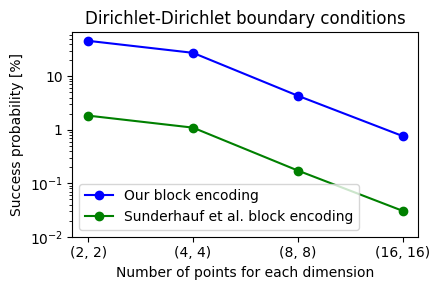

In [ ]:
nqs = list(range(1, 5))
n_points = 2 ** (2 * np.array(nqs))

sprob_our_be_2d_dbc = []
sprob_sunderhauf_be_2d_dbc = []
sprob_fable_2d_dbc = []

for i in range(len(nqs)):
    nq = nqs[i]
    x = np.linspace(0, 1, 2**nq, endpoint=False)
    v_normed = prepare_v_vector([nq, nq], v_2d)

    # Our block encoding
    qc = generate_laplacian_block_encoding([nq, nq], vs=v_normed)
    unitary = get_circuit_unitary(qc, [nq, nq])
    sprob_our_be_2d_dbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # Sunderhauf et al.
    qc_sunderhauf_be = sunderhauf_block_encoding(2**nq, 2**nq, generate_laplacian((2**nq, 2**nq), analytic_normalize=True), v_normed)
    unitary = get_circuit_unitary(qc_sunderhauf_be, [nq, nq])
    sprob_sunderhauf_be_2d_dbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)


plt.figure(figsize=(5, 4))
plt.plot(n_points, sprob_our_be_2d_dbc, "o-", color="blue", label="Our block encoding")
plt.plot(n_points, sprob_sunderhauf_be_2d_dbc, "o-", color="green", label="Sunderhauf et al. block encoding")

plt.xscale("log")
plt.xticks([4, 16, 64, 256], ["(2, 2)", "(4, 4)", "(8, 8)", "(16, 16)"])
plt.tick_params(axis='x', which='minor', bottom=False)
plt.xlabel("Number of points for each dimension")

plt.yscale("log")
y_ticks = [10**(-i) for i in range(-1, 3)]
y_labels = ["10", "1"] + [f"$10^{{{-i}}}$" for i in range(1, 3)]
plt.yticks(y_ticks, y_labels)
plt.ylabel("Success probability [%]")


plt.title("Dirichlet-Dirichlet boundary conditions")
plt.legend()
plt.tight_layout()
plt.show()